<a href="https://colab.research.google.com/github/19mddill/Machine_Learning_Notebooks/blob/main/unsupervised_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# K-means


In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans

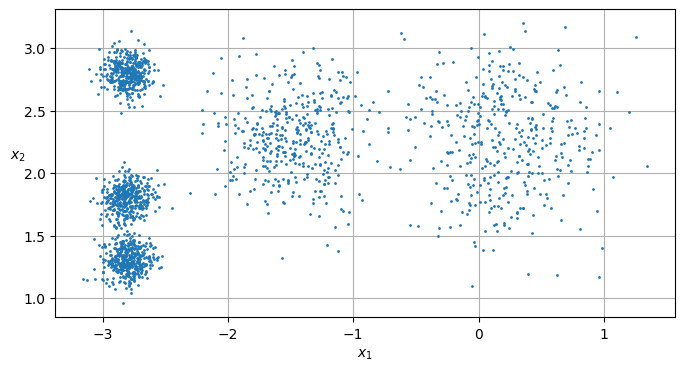

In [2]:
blob_centers = np.array([[ 0.2,  2.3], [-1.5 ,  2.3], [-2.8,  1.8],[-2.8,  2.8], [-2.8,  1.3]])
blob_std = np.array([0.4, 0.3, 0.1, 0.1, 0.1])
X, y = make_blobs(n_samples=2000, centers=blob_centers, cluster_std=blob_std,random_state=7)

def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.gca().set_axisbelow(True)
plt.grid()
plt.show()

In [3]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

In [4]:
y_pred

array([2, 2, 4, ..., 1, 4, 2], dtype=int32)

In [5]:
y_pred is kmeans.labels_

True

In [6]:
kmeans.cluster_centers_,blob_centers

(array([[-0.066884  ,  2.10378803],
        [-2.79290307,  2.79641063],
        [-2.80214068,  1.55162671],
        [-1.47468607,  2.28399066],
        [ 0.47042841,  2.41380533]]),
 array([[ 0.2,  2.3],
        [-1.5,  2.3],
        [-2.8,  1.8],
        [-2.8,  2.8],
        [-2.8,  1.3]]))

In [7]:
X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])
kmeans.predict(X_new)

array([0, 0, 0, 4], dtype=int32)

In [8]:
kmeans.transform(X_new).round(2)

array([[2.15, 3.62, 2.78, 2.48, 2.6 ],
       [1.61, 3.62, 2.99, 2.31, 1.97],
       [2.45, 4.77, 4.15, 3.44, 2.57],
       [2.34, 5.12, 4.83, 3.7 , 2.08]])

In [9]:
kmeans.inertia_

224.0743312251571

In [10]:
kmeans.score(X)

-224.0743312251571

# MINI BATCH Clustering

In [11]:
from sklearn.cluster import MiniBatchKMeans

In [12]:
minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

MiniBatchKMeans(n_clusters=5, random_state=42)

In [13]:
minibatch_kmeans.inertia_

211.65945105712612

100/100

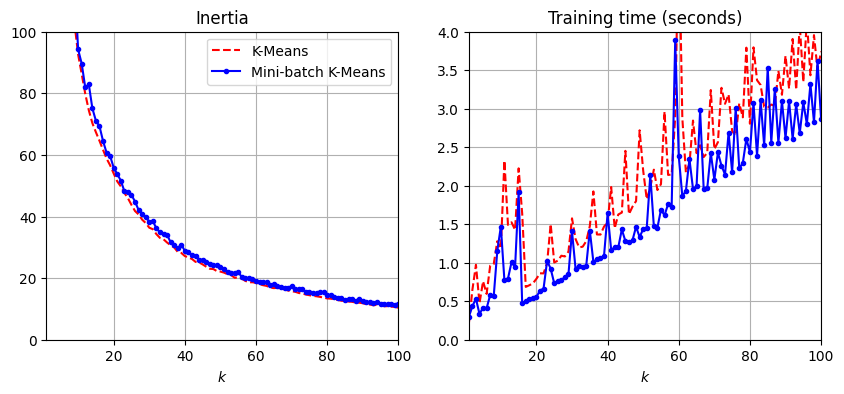

In [14]:
from timeit import timeit

max_k = 100
times = np.empty((max_k, 2))
inertias = np.empty((max_k, 2))
for k in range(1, max_k + 1):
    kmeans_ = KMeans(n_clusters=k, algorithm="lloyd", n_init=10, random_state=42)
    minibatch_kmeans = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=42)
    print(f"\r{k}/{max_k}", end="")  # \r returns to the start of line
    times[k - 1, 0] = timeit("kmeans_.fit(X)", number=10, globals=globals())
    times[k - 1, 1] = timeit("minibatch_kmeans.fit(X)", number=10,
                             globals=globals())
    inertias[k - 1, 0] = kmeans_.inertia_
    inertias[k - 1, 1] = minibatch_kmeans.inertia_

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.plot(range(1, max_k + 1), inertias[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), inertias[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Inertia")
plt.legend()
plt.axis([1, max_k, 0, 100])
plt.grid()

plt.subplot(122)
plt.plot(range(1, max_k + 1), times[:, 0], "r--", label="K-Means")
plt.plot(range(1, max_k + 1), times[:, 1], "b.-", label="Mini-batch K-Means")
plt.xlabel("$k$")
plt.title("Training time (seconds)")
plt.axis([1, max_k, 0, 4])
plt.grid()
plt.show()

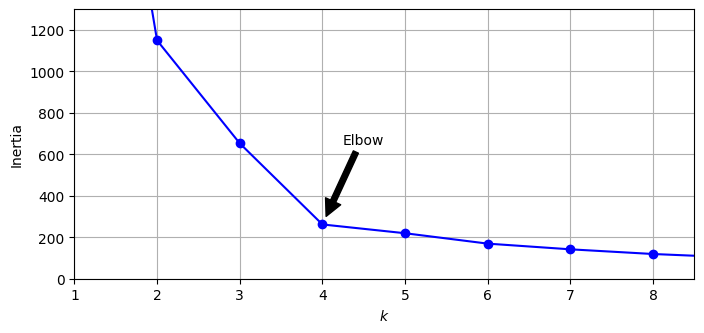

In [15]:
kmeans_per_k = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
                for k in range(1, 10)]
inertias = [model.inertia_ for model in kmeans_per_k]

plt.figure(figsize=(8, 3.5))
plt.plot(range(1, 10), inertias, "bo-")
plt.xlabel("$k$")
plt.ylabel("Inertia")
plt.annotate("", xy=(4, inertias[3]), xytext=(4.45, 650),
             arrowprops=dict(facecolor='black', shrink=0.1))
plt.text(4.5, 650, "Elbow", horizontalalignment="center")
plt.axis([1, 8.5, 0, 1300])
plt.grid()
plt.show()

# Silhouette Score

In [16]:
from sklearn.metrics import silhouette_score



In [17]:
silhouette_score(X,kmeans.labels_)

np.float64(0.6267891051050735)

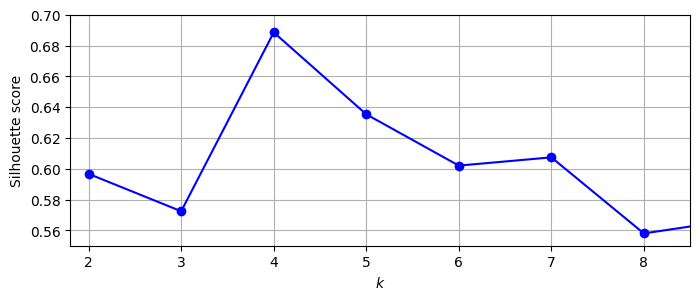

In [18]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.xlabel("$k$")
plt.ylabel("Silhouette score")
plt.axis([1.8, 8.5, 0.55, 0.7])
plt.grid()
plt.show()

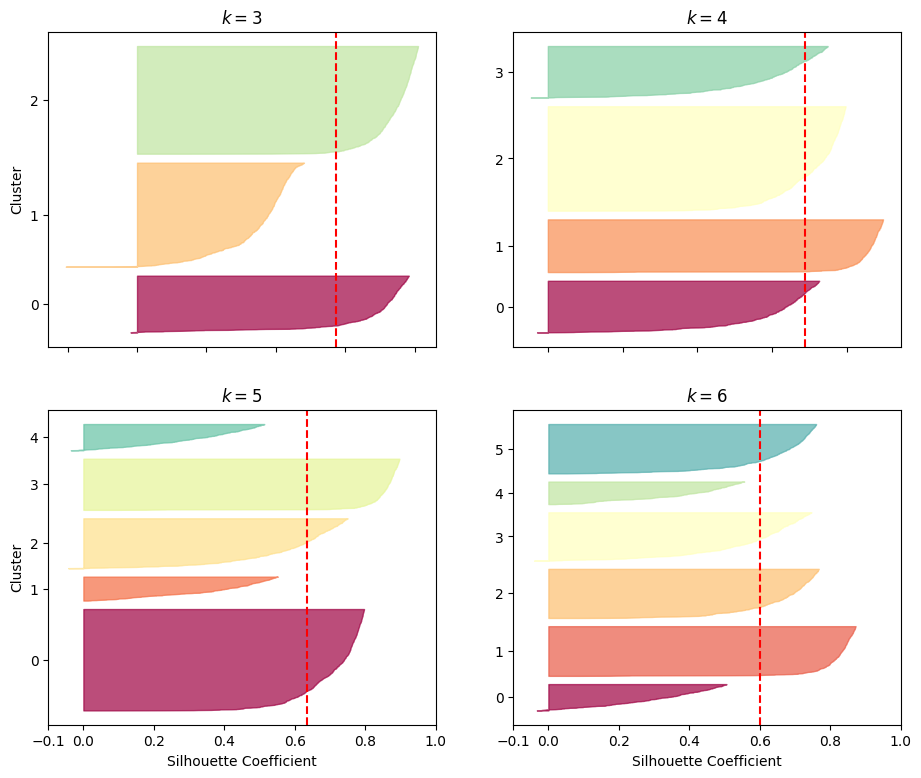

In [19]:
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter

plt.figure(figsize=(11, 9))

for k in (3, 4, 5, 6):
    plt.subplot(2, 2, k - 2)

    y_pred = kmeans_per_k[k - 1].labels_
    silhouette_coefficients = silhouette_samples(X, y_pred)

    padding = len(X) // 30
    pos = padding
    ticks = []
    for i in range(k):
        coeffs = silhouette_coefficients[y_pred == i]
        coeffs.sort()

        color = plt.cm.Spectral(i / k)
        plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                          facecolor=color, edgecolor=color, alpha=0.7)
        ticks.append(pos + len(coeffs) // 2)
        pos += len(coeffs) + padding

    plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().yaxis.set_major_formatter(FixedFormatter(range(k)))
    if k in (3, 5):
        plt.ylabel("Cluster")

    if k in (5, 6):
        plt.gca().set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
        plt.xlabel("Silhouette Coefficient")
    else:
        plt.tick_params(labelbottom=False)

    plt.axvline(x=silhouette_scores[k - 2], color="red", linestyle="--")
    plt.title(f"$k={k}$")

plt.show()

# Image Segmentation Using KMeans



In [20]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "unsupervised_learning"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

In [23]:
import PIL
filename = "ladybug.png"
filepath = IMAGES_PATH / filename
image = np.asarray(PIL.Image.open(filepath))
image.shape

(533, 800, 3)

array([[[ 25,  29,   2],
        [ 24,  28,   1],
        [ 24,  29,   0],
        ...,
        [ 57, 105,  21],
        [ 56, 103,  22],
        [ 52,  99,  19]],

       [[ 24,  28,   1],
        [ 23,  27,   0],
        [ 23,  27,   0],
        ...,
        [ 60, 108,  22],
        [ 59, 106,  25],
        [ 55, 102,  22]],

       [[ 23,  27,   2],
        [ 22,  26,   1],
        [ 22,  26,   0],
        ...,
        [ 66, 114,  28],
        [ 63, 111,  27],
        [ 58, 105,  24]],

       ...,

       [[ 14,  18,   1],
        [ 14,  18,   1],
        [ 13,  20,   2],
        ...,
        [ 13,  61,   3],
        [  9,  56,   2],
        [  5,  51,   2]],

       [[ 14,  18,   1],
        [ 14,  18,   1],
        [ 12,  19,   1],
        ...,
        [ 11,  59,   1],
        [  7,  54,   0],
        [  3,  49,   0]],

       [[ 13,  17,   0],
        [ 13,  17,   0],
        [ 11,  18,   0],
        ...,
        [ 10,  58,   0],
        [  5,  52,   0],
        [  2,  48,   0]]], dtype=uint8)
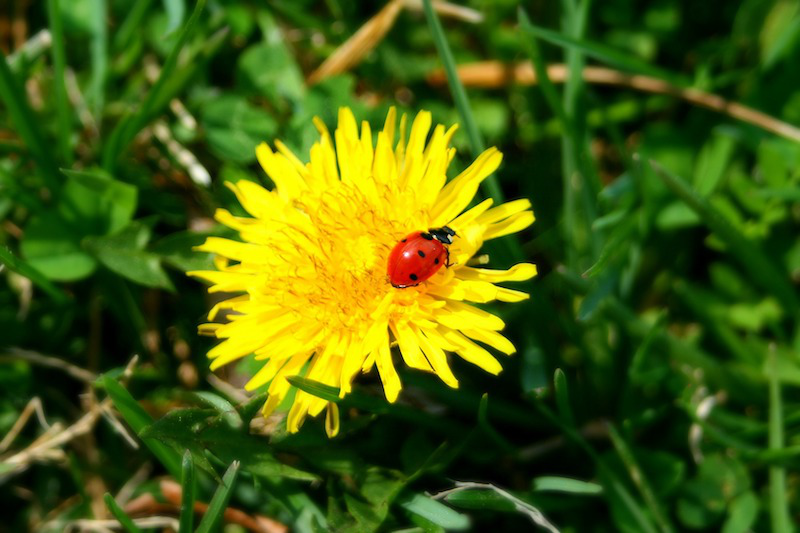

In [25]:
image

In [26]:
X = image.reshape(-1,3)

In [27]:
kmeans = KMeans(n_clusters = 8,random_state=42).fit(X)

In [28]:
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

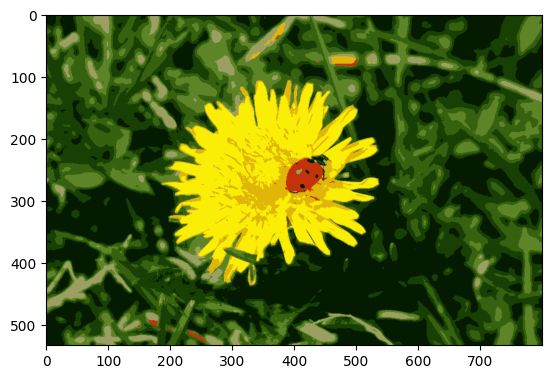

In [29]:
plt.imshow(segmented_img/255)

##**Fany Indexing** Intution

In [30]:
centers = np.array([10,20,30])
labels = np.array([0,2,1,0,2])

In [31]:
centers[labels]

array([10, 30, 20, 10, 30])

# Clustering for Semi Supervised Learning

In [1]:
from timeit import timeit
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
from pathlib import Path
import PIL
from sklearn.datasets import load_digits
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.datasets import make_blobs


In [33]:
X_digits, y_digits = load_digits(return_X_y=True)
X_train,y_train = X_digits[:1400],y_digits[:1400]
X_test, y_test = X_digits[1400:],y_digits[1400:]

In [34]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train[:n_labeled],y_train[:n_labeled])

LogisticRegression(max_iter=10000)

In [35]:
log_reg.score(X_test, y_test)

0.7581863979848866

In [36]:
k = 50
kmeans = KMeans(n_clusters=k, random_state=4)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis = 0)
X_representative_digits = X_train[representative_digit_idx]

In [37]:
X_representative_digits

array([[ 0.,  0.,  0., ..., 15.,  8.,  0.],
       [ 0.,  0.,  6., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 15.,  8.,  0.],
       ...,
       [ 0.,  1., 15., ...,  0.,  0.,  0.],
       [ 0.,  0.,  4., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.]])

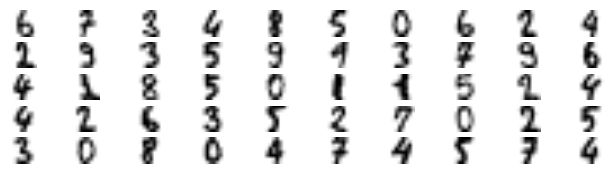

In [38]:


plt.figure(figsize=(8, 2))
for index, X_representative_digit in enumerate(X_representative_digits):
    plt.subplot(k // 10, 10, index + 1)
    plt.imshow(X_representative_digit.reshape(8, 8), cmap="binary",
               interpolation="bilinear")
    plt.axis('off')

plt.show()

In [39]:
y_representative_digits = np.array([
     6, 7, 3, 4, 8, 5, 0, 6, 2, 4,
     2, 9, 3, 5, 9, 9, 3, 7, 9, 6,
     4, 1, 8, 5, 0, 1, 1, 5, 2, 4,
     4, 2, 6, 3, 5, 2, 7, 0, 2, 5,
     3, 0, 8, 0, 4, 7, 4, 5, 7, 4
])

In [40]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.818639798488665

In [41]:
kmeans.labels_[:100]

array([24, 25, 35, 40,  3, 11, 32,  1, 22, 11, 24, 26, 10, 16, 30, 39,  0,
       45, 42, 11, 43, 26, 10, 16,  9, 39, 32, 48,  4, 11, 41, 11, 13, 23,
        0, 23, 43, 11, 42, 18,  4, 30, 26, 48,  1, 12, 23, 26, 37, 37, 35,
       35, 48,  4, 35, 43, 26, 35, 32, 16, 16, 45, 16, 16, 30, 32, 32,  7,
       29,  1, 26, 13, 43, 11,  5, 35, 42, 35,  6,  6, 26, 45, 32, 16, 31,
       26, 48, 29, 32, 16, 26, 16, 33, 25, 45, 32, 42,  9, 16, 25],
      dtype=int32)

# **Label Propagation**




In [42]:

y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [43]:
log_reg = LogisticRegression(max_iter=10_000)
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

0.8740554156171285

# Removing Outliers

In [44]:
percentile_closest = 98

X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]
for i in range(k):
    in_cluster = (kmeans.labels_ == i)
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = (X_cluster_dist > cutoff_distance)
    X_cluster_dist[in_cluster & above_cutoff] = -1

partially_propagated = (X_cluster_dist != -1)
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [45]:
log_reg_partial = LogisticRegression(max_iter=10_000)
log_reg_partial.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg_partial.score(X_test, y_test)


0.8740554156171285

# **Propagation Accuracy**

In [46]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

np.float64(0.9607116382505559)

# **DBSCAN**

In [47]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

In [48]:
X, y = make_moons(n_samples=1000,noise=0.05)
dbscan = DBSCAN(eps=0.05,min_samples=5)
dbscan.fit(X)

DBSCAN(eps=0.05)

In [49]:
dbscan.labels_[:100]

array([ 0,  7,  1,  0,  2,  2,  3,  4,  5,  2,  6,  2,  0,  7,  3,  7,  3,
        1,  8, 10,  2,  9,  1,  5,  6,  1,  6,  0,  2,  1,  0,  8,  2,  1,
        2,  2,  1,  8,  6,  1,  7,  3,  7,  8,  0,  3,  9,  3,  0,  7,  8,
        7,  1,  3,  3,  0, -1,  4,  5,  2,  8, -1,  0,  1,  6, -1,  6,  1,
        6,  0,  1,  7,  3, 10,  3,  5,  5,  1,  6,  7,  0,  2,  3,  1,  5,
        5,  6,  0,  0,  0,  0,  7,  2,  1,  3,  8,  2, -1,  5,  3])

In [50]:
dbscan.core_sample_indices_[:100]

array([  0,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  20,  21,  22,  23,  24,  25,  27,  28,
        29,  30,  31,  33,  34,  36,  37,  38,  39,  40,  41,  42,  43,
        44,  45,  46,  48,  49,  50,  51,  52,  53,  55,  57,  58,  59,
        62,  63,  64,  66,  67,  68,  70,  71,  72,  73,  74,  75,  76,
        77,  78,  80,  81,  82,  83,  84,  85,  86,  87,  88,  90,  91,
        92,  93,  94,  95,  96,  98,  99, 101, 102, 104, 105, 106, 108,
       109, 110, 111, 112, 113, 114, 115, 117, 118])

In [51]:
dbscan.components_[:5]

array([[ 1.14650423, -0.45052699],
       [ 1.91777345, -0.06792976],
       [ 0.76807453, -0.42018265],
       [ 0.16444398, -0.12957642],
       [ 0.07217709,  0.42133227]])

In [52]:
X[0],X[1],X[2],X[4],X[5]

(array([ 1.14650423, -0.45052699]),
 array([-0.8085905 ,  0.65680461]),
 array([ 1.91777345, -0.06792976]),
 array([ 0.16444398, -0.12957642]),
 array([0.07217709, 0.42133227]))

In [53]:
dbscan.components_[7],X[9]

(array([0.92096965, 0.40059161]), array([0.0507696 , 0.40354183]))

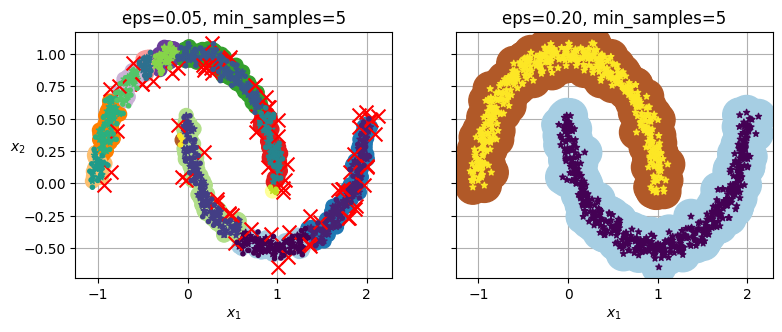

In [54]:
# extra code – this cell generates and saves Figure 9–14

def plot_dbscan(dbscan, X, size, show_xlabels=True, show_ylabels=True):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20,
                c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1],
                c=dbscan.labels_[non_core_mask], marker=".")
    if show_xlabels:
        plt.xlabel("$x_1$")
    else:
        plt.tick_params(labelbottom=False)
    if show_ylabels:
        plt.ylabel("$x_2$", rotation=0)
    else:
        plt.tick_params(labelleft=False)
    plt.title(f"eps={dbscan.eps:.2f}, min_samples={dbscan.min_samples}")
    plt.grid()
    plt.gca().set_axisbelow(True)

dbscan2 = DBSCAN(eps=0.2)
dbscan2.fit(X)

plt.figure(figsize=(9, 3.2))

plt.subplot(121)
plot_dbscan(dbscan, X, size=100)

plt.subplot(122)
plot_dbscan(dbscan2, X, size=600, show_ylabels=False)
plt.show()

In [55]:
from sklearn.neighbors import KNeighborsClassifier

dbscan =dbscan2
knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

KNeighborsClassifier(n_neighbors=50)

In [56]:
X_new = np.array([[-0.5,0],[0,0.5],[1,-0.1],[2,1]])

In [57]:
knn.predict(X_new)

array([1, 0, 1, 0])

In [58]:
knn.predict_proba(X_new)

array([[0.18, 0.82],
       [1.  , 0.  ],
       [0.12, 0.88],
       [1.  , 0.  ]])

## Detecting Anamolies

In [62]:
  y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors=1)
  y_dist,y_pred_idx


(array([[0.36688641],
        [0.0213861 ],
        [0.03498823],
        [0.45195719]]),
 array([[133],
        [953],
        [ 19],
        [964]]))

In [63]:
  y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
  y_pred[y_dist > 0.2] = -1
  y_pred.ravel()

array([-1,  0,  1, -1])

# **Gaussian Mixtures**

In [6]:
from sklearn.mixture import GaussianMixture

In [7]:
X1, y1 = make_blobs(n_samples=1000, centers=((4, -4), (0, 0)), random_state=42)
X1 = X1.dot(np.array([[0.374, 0.95], [0.732, 0.598]]))
X2, y2 = make_blobs(n_samples=250, centers=1, random_state=42)
X2 = X2 + [6, -8]
X = np.r_[X1, X2]
y = np.r_[y1, y2]

In [9]:
gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

GaussianMixture(n_components=3, n_init=10, random_state=42)

In [10]:
gm.weights_

array([0.40005972, 0.20961444, 0.39032584])

In [11]:
gm.means_

array([[-1.40764129,  1.42712848],
       [ 3.39947665,  1.05931088],
       [ 0.05145113,  0.07534576]])

In [12]:
gm.covariances_

array([[[ 0.63478217,  0.72970097],
        [ 0.72970097,  1.16094925]],

       [[ 1.14740131, -0.03271106],
        [-0.03271106,  0.95498333]],

       [[ 0.68825143,  0.79617956],
        [ 0.79617956,  1.21242183]]])

In [13]:
gm.converged_

True

In [14]:
gm.n_iter_

4

In [15]:
gm.predict(X)

array([2, 2, 0, ..., 1, 1, 1])

In [16]:
gm.predict_proba(X).round(3)

array([[0.   , 0.023, 0.977],
       [0.001, 0.016, 0.983],
       [1.   , 0.   , 0.   ],
       ...,
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ],
       [0.   , 1.   , 0.   ]])